<function matplotlib.pyplot.show(close=None, block=None)>

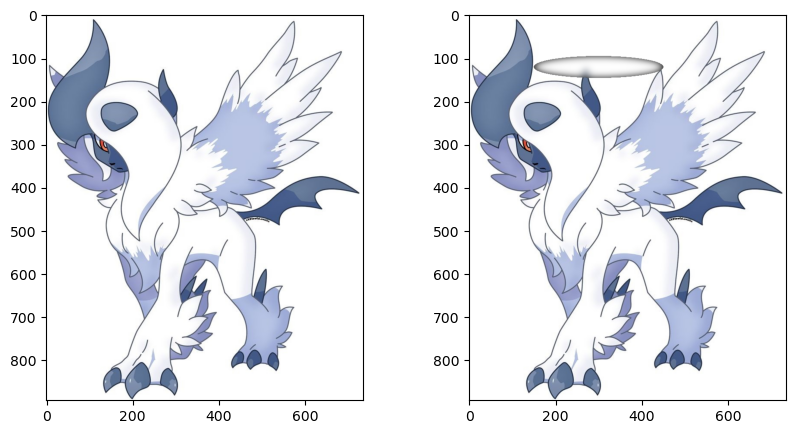

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def desenfoqueRoi(img,centro,x,y):
    img1 = np.copy(img)
    valx,valy = centro
    mediox = x//2
    medioy = y//2
    mascara = np.zeros_like(img,dtype=np.uint8)
    cv2.ellipse(mascara,(valx,valy),(mediox,medioy),0,0,360,(255,255,255),-1)
    img_Mask = cv2.bitwise_and(img,mascara)
    desenfoque = cv2.GaussianBlur(img_Mask,(55,55),0)#lugar para aumentra el desenfoque
    img1[mascara!=0]=desenfoque[mascara!=0]
    return img1

imagen = cv2.imread('absol1.jpeg')

imagenrgb = cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB)
img_desenfoque = desenfoqueRoi(imagenrgb,(300,120),300,50)#pocicion de la gota
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(imagenrgb)
plt.subplot(1,2,2)
plt.imshow(img_desenfoque)

plt.show


TODO LAS FUNCIONES UNIDAS

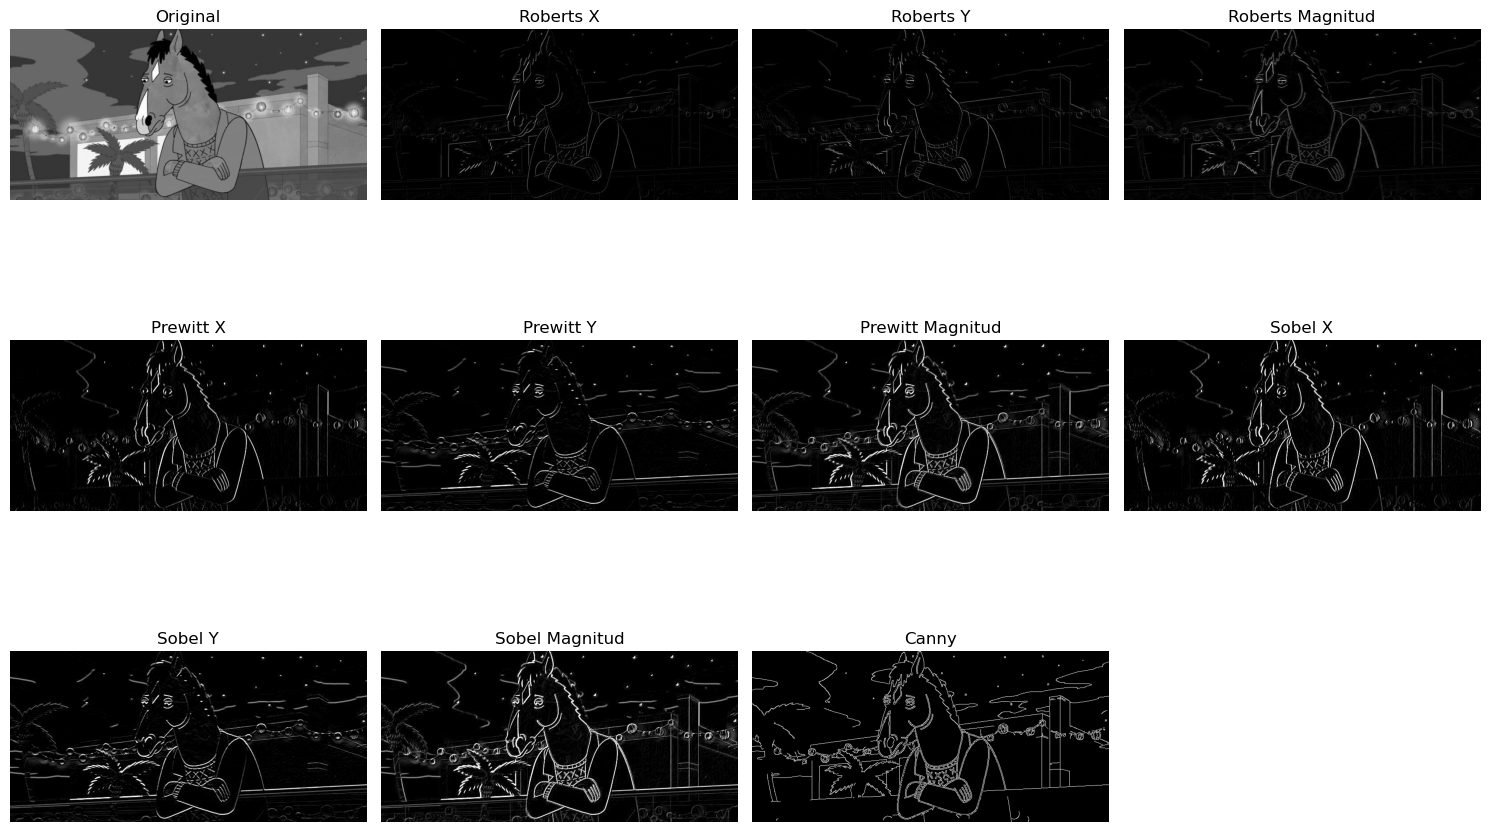

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imagen y convertir a escala de grises
img = cv2.imread('cawallo.jpeg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Filtro de Roberts
robertsx = np.array([[-1, 0], [0, 1]])
robertsy = np.array([[0, -1], [1, 0]])

img_robx = cv2.filter2D(img_gray, -1, robertsx)
img_roby = cv2.filter2D(img_gray, -1, robertsy)

rob_gMagnitud = np.sqrt(img_robx.astype(float)**2 + img_roby.astype(float)**2)
rob_gDireccion = np.arctan2(img_roby, img_robx)

# Filtro de Prewitt
prewittx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
prewitty = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])

img_prewx = cv2.filter2D(img_gray, -1, prewittx)
img_prewy = cv2.filter2D(img_gray, -1, prewitty)

prew_mag = np.sqrt(img_prewx.astype(float)**2 + img_prewy.astype(float)**2)
prew_mag = np.uint8(np.clip(prew_mag, 0, 255))

# Filtro de Sobel
sobelx = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
sobely = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

sogx_img = cv2.filter2D(img_gray, -1, sobelx)
sogy_img = cv2.filter2D(img_gray, -1, sobely)

sobel_grad = np.sqrt(sogx_img.astype(float)**2 + sogy_img.astype(float)**2)
sobel_grad = np.uint8(np.clip(sobel_grad, 0, 255))

# Canny
canny = cv2.Canny(img_gray, 100, 200)

titles = ['Original', 'Roberts X', 'Roberts Y', 'Roberts Magnitud',
          'Prewitt X', 'Prewitt Y', 'Prewitt Magnitud',
          'Sobel X', 'Sobel Y', 'Sobel Magnitud',
          'Canny']
images = [img_gray, img_robx, img_roby, rob_gMagnitud,
          img_prewx, img_prewy, prew_mag,
          sogx_img, sogy_img, sobel_grad,
          canny]

plt.figure(figsize=(15, 10))
for i in range(len(images)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


ROBERT MEJORADO

Text(0.5, 1.0, 'Bordes Detectados')

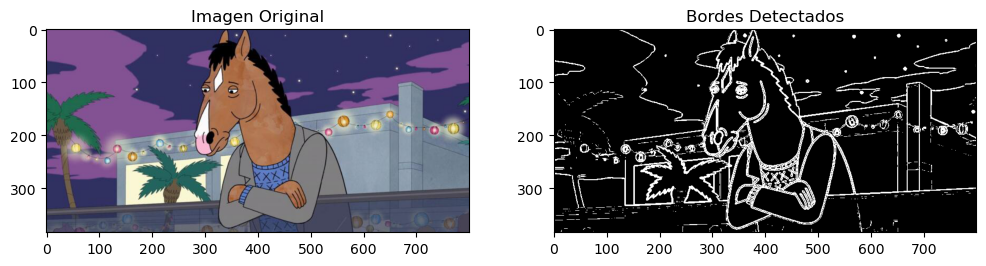

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def robert_mejorado(imagen):
    img_gray =cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)
    suavizado = cv2.GaussianBlur(img_gray,(3,3),0)
    kernelx = np.array([[2,0],[0,-2]],dtype=np.float32)
    kernely = np.array([[0,2],[-2,0]],dtype=np.float32)
    robx = cv2.filter2D(suavizado,cv2.CV_16S,kernelx)
    roby = cv2.filter2D(suavizado,cv2.CV_16S,kernely)
    roberts = cv2.addWeighted(np.abs(robx),0.7,np.abs(roby),0.7,0)
    _,bordes = cv2.threshold(roberts,30,255,cv2.THRESH_BINARY)
    return bordes

imagen = cv2.imread('cawallo.jpeg')

resultado = robert_mejorado(imagen)


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')

plt.subplot(1, 2, 2)
plt.imshow(resultado, cmap='gray')
plt.title('Bordes Detectados')



SOBEL MEJORADO

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18916\1858731590.py:10: RuntimeWarning: invalid value encountered in sqrt
  magnitud = np.sqrt(sobelx*2 + sobely*2)


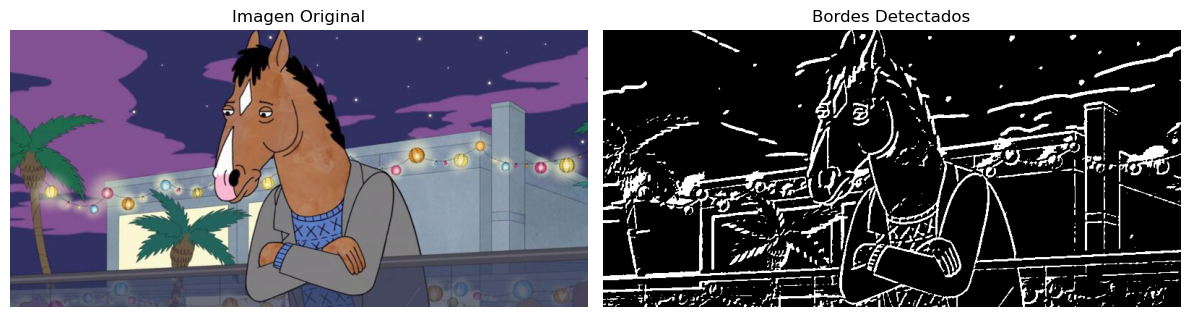

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def sobel_mejorado(imagen, tam_kernel=3, umbral=30):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    img_blur = cv2.GaussianBlur(img_gray, (3, 3), 0)
    sobelx = cv2.Sobel(img_blur, cv2.CV_16S, 1, 0, ksize=tam_kernel)
    sobely = cv2.Sobel(img_blur, cv2.CV_16S, 0, 1, ksize=tam_kernel)
    magnitud = np.sqrt(sobelx*2 + sobely*2)
    magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    _, bordes = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    kernel_morfologico = np.ones((2, 2), np.uint8)
    bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_morfologico)
    return bordes

imagen = cv2.imread('cawallo.jpeg')

bordes = sobel_mejorado(imagen)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')

plt.subplot(1, 2, 2)
plt.imshow(bordes, cmap='gray')
plt.title('Bordes Detectados')

plt.show()

PREWITT MEJORADO

Text(0.5, 1.0, 'Bordes Detectados')

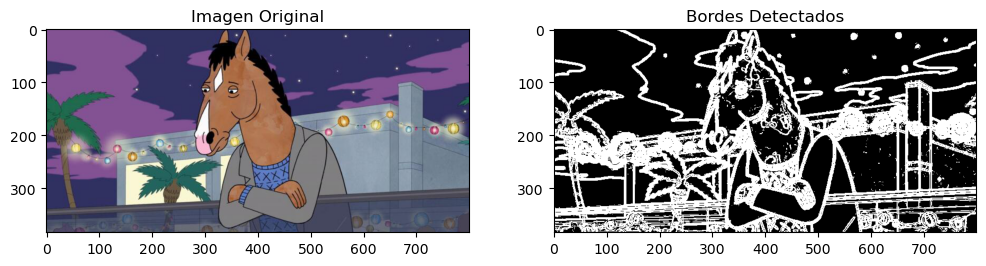

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def prewitt_mejor(imagen):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.GaussianBlur(img_gray, (3, 3), 0)
    
    prewittx = np.array([[3,0,-3],[3,0,-3],[3,0,-3]],dtype=np.float32)
    prewitty = np.array([[3,3,3],[0,0,0],[-3,-3,-3]],dtype=np.float32)
    x = cv2.filter2D(img_gray,cv2.CV_64F,prewittx)
    y = cv2.filter2D(img_gray,cv2.CV_64F,prewitty)
    magnitud = np.sqrt(x**2+y**2)
    _,bordes = cv2.threshold(magnitud,30,255,cv2.THRESH_BINARY)
    return bordes

imagen = cv2.imread('cawallo.jpeg')

bordes = prewitt_mejor(imagen)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')

plt.subplot(1, 2, 2)
plt.imshow(bordes, cmap='gray')
plt.title('Bordes Detectados')

TRABAJO EN AULA

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18916\1641611313.py:61: RuntimeWarning: invalid value encountered in sqrt
  magnitud = np.sqrt(sobelx*2 + sobely*2)


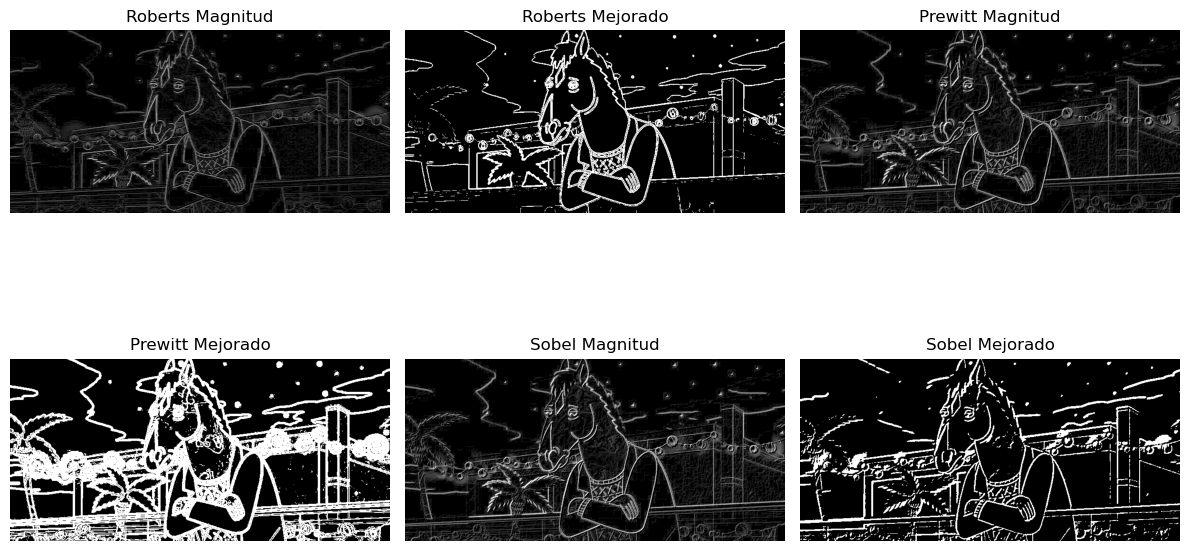

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt



def roberts(img_gray):
    robertsx = np.array([[-1, 0], [0, 1]])
    robertsy = np.array([[0, -1], [1, 0]])
    img_robx = cv2.filter2D(img_gray, -1, robertsx)
    img_roby = cv2.filter2D(img_gray, -1, robertsy)
    rob_gMagnitud = np.sqrt(img_robx.astype(float)*2 + img_roby.astype(float)*2)
    rob_gDireccion = np.arctan2(img_roby, img_robx)
    return img_robx, img_roby, rob_gMagnitud, rob_gDireccion

def robert_mejorado(imagen):
    img_gray =cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)
    suavizado = cv2.GaussianBlur(img_gray,(3,3),0)
    kernelx = np.array([[2,0],[0,-2]],dtype=np.float32)
    kernely = np.array([[0,2],[-2,0]],dtype=np.float32)
    robx = cv2.filter2D(suavizado,cv2.CV_16S,kernelx)
    roby = cv2.filter2D(suavizado,cv2.CV_16S,kernely)
    roberts = cv2.addWeighted(np.abs(robx),0.7,np.abs(roby),0.7,0)
    _,bordes = cv2.threshold(roberts,30,255,cv2.THRESH_BINARY)
    return bordes

def prewitt(img_gray):
    prewittx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
    prewitty = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
    img_prewx = cv2.filter2D(img_gray, -1, prewittx)
    img_prewy = cv2.filter2D(img_gray, -1, prewitty)
    prew_mag = np.sqrt(img_prewx.astype(float)*2 + img_prewy.astype(float)*2)
    prew_mag = np.uint8(np.clip(prew_mag, 0, 255))
    return img_prewx, img_prewy, prew_mag

def prewitt_mejor(imagen):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.GaussianBlur(img_gray, (3, 3), 0)
    prewittx = np.array([[3,0,-3],[3,0,-3],[3,0,-3]],dtype=np.float32)
    prewitty = np.array([[3,3,3],[0,0,0],[-3,-3,-3]],dtype=np.float32)
    x = cv2.filter2D(img_gray,cv2.CV_64F,prewittx)
    y = cv2.filter2D(img_gray,cv2.CV_64F,prewitty)
    magnitud = np.sqrt(x**2+y**2)
    _,bordes = cv2.threshold(magnitud,30,255,cv2.THRESH_BINARY)
    return bordes

def filtro_sobel(img_gray):
    sobelx = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
    sobely = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])
    sogx_img = cv2.filter2D(img_gray, -1, sobelx)
    sogy_img = cv2.filter2D(img_gray, -1, sobely)
    sobel_grad = np.sqrt(sogx_img.astype(float)*2 + sogy_img.astype(float)*2)
    sobel_grad = np.uint8(np.clip(sobel_grad, 0, 255))
    return sogx_img, sogy_img, sobel_grad

def sobel_mejorado(imagen, tam_kernel=3, umbral=30):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    img_blur = cv2.GaussianBlur(img_gray, (3, 3), 0)
    sobelx = cv2.Sobel(img_blur, cv2.CV_16S, 1, 0, ksize=tam_kernel)
    sobely = cv2.Sobel(img_blur, cv2.CV_16S, 0, 1, ksize=tam_kernel)
    magnitud = np.sqrt(sobelx*2 + sobely*2)
    magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    _, bordes = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    kernel_morfologico = np.ones((2, 2), np.uint8)
    bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_morfologico)
    return bordes

def mostrar_resultados(imagen):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    _, _, roberts_mag, _ = roberts(img_gray)
    roberts_mejor = robert_mejorado(imagen)
    _, _, prewitt_mag = prewitt(img_gray)
    prewitt_mejorado_result = prewitt_mejor(imagen)
    _, _, sobel_mag = filtro_sobel(img_gray)
    sobel_mejorado_result = sobel_mejorado(imagen)
    titulos = ['Roberts Magnitud', 'Roberts Mejorado','Prewitt Magnitud', 'Prewitt Mejorado','Sobel Magnitud', 'Sobel Mejorado']
    imagenes = [roberts_mag, roberts_mejor,prewitt_mag, prewitt_mejorado_result,sobel_mag, sobel_mejorado_result]
    plt.figure(figsize=(12, 8))
    for i in range(len(imagenes)):
        plt.subplot(2, 3, i+1)
        plt.imshow(imagenes[i], cmap='gray')
        plt.title(titulos[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

imagen = cv2.imread('cawallo.jpeg')
mostrar_resultados(imagen)